In [1]:
"""
Customer Churn Prediction with KNN
Author: Armin Seyfi
Description: Predict whether a customer will churn or not using KNN
"""
  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)
print(df.columns)
df.info()

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str   


BASIC STATISTICS

Dataset shape:
(7043, 21)

Numeric features:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

Categorical features:
        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     7590-VHVEG   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count           

/var/folders/t6/ch9z5wm51qddprhtl2_2t6pr0000gn/T/ipykernel_81511/1126385258.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


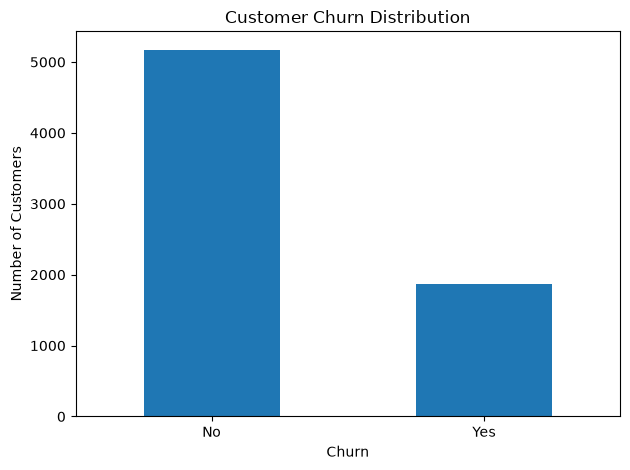


NUMERIC FEATURE DISTRIBUTIONS
Saved visualization to 'numeric_feature_distributions.png'


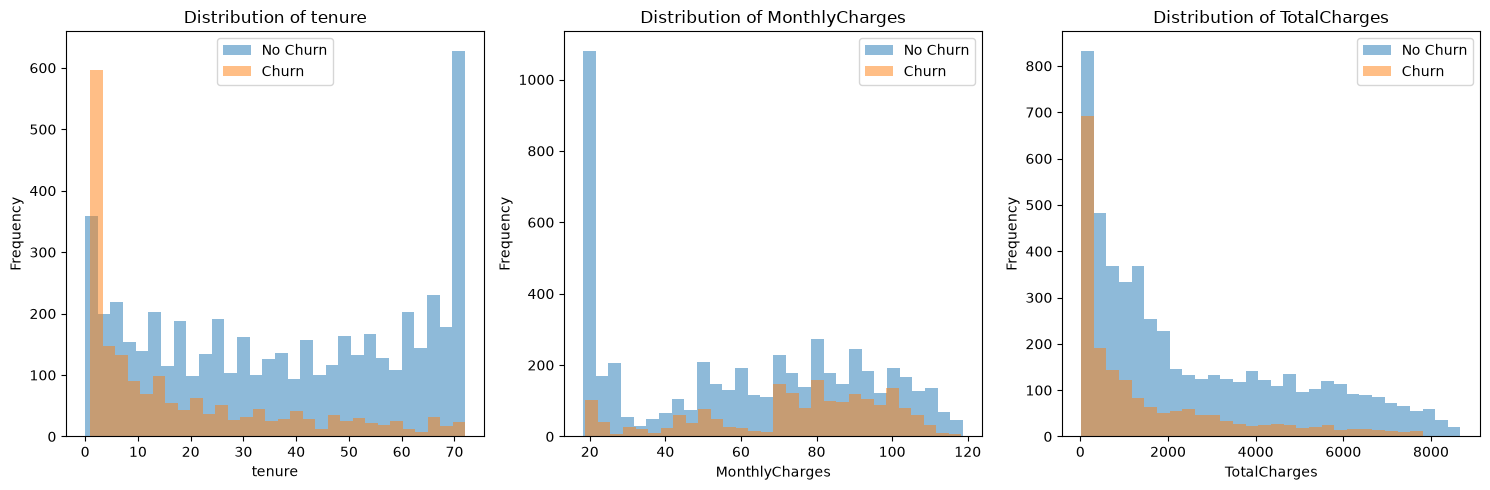


CATEGORICAL FEATURE DISTRIBUTIONS
Saved visualization to 'categorical_feature_distributions.png'


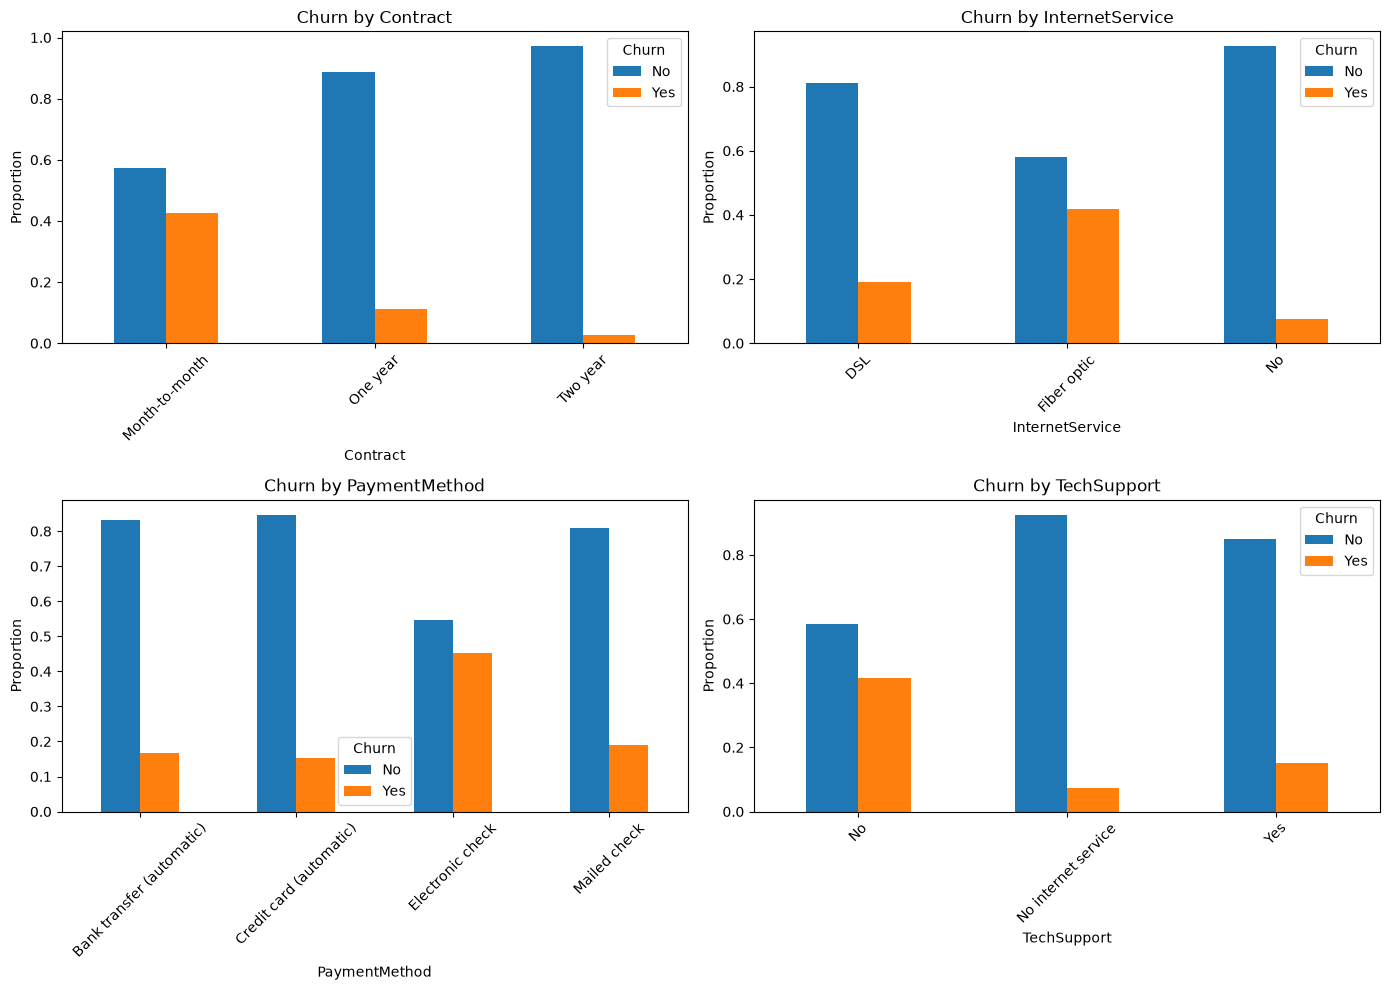

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


# ==================================================
# BASIC STATISTICS
# ==================================================

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)

print("\nDataset shape:")
print(df.shape)

print("\nNumeric features:")
print(df.describe())

print("\nCategorical features:")
print(df.describe(include="object"))


# ==================================================
# CHECK TARGET DISTRIBUTION
# ==================================================

print("\n" + "=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)

churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

print("\nCounts:")
print(churn_counts)

print("\nPercentages:")
print(churn_percentages.round(2))


# ==================================================
# CHECK FOR MISSING VALUES
# ==================================================

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)

missing = df.isnull().sum()

if missing.sum() == 0:
    print("✓ No standard missing values found!")
else:
    print(missing[missing > 0])


# ==================================================
# CHECK TOTALCHARGES
# ==================================================

print("\n" + "=" * 50)
print("TOTALCHARGES CHECK")
print("=" * 50)

print("Current dtype:", df["TotalCharges"].dtype)

# Convert TotalCharges to numeric
# Invalid values such as blank strings become NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("New dtype:", df["TotalCharges"].dtype)

print("\nMissing values after conversion:")
print(df["TotalCharges"].isnull().sum())


# ==================================================
# VISUALIZE TARGET DISTRIBUTION
# ==================================================

print("\n" + "=" * 50)
print("CHURN DISTRIBUTION")
print("=" * 50)

churn_counts.plot(
    kind="bar"
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "churn_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

print("Saved visualization to 'churn_distribution.png'")

plt.show()


# ==================================================
# VISUALIZE NUMERIC FEATURE DISTRIBUTIONS
# ==================================================

print("\n" + "=" * 50)
print("NUMERIC FEATURE DISTRIBUTIONS")
print("=" * 50)

key_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for idx, feature in enumerate(key_features):

    axes[idx].hist(
        df[df["Churn"] == "No"][feature].dropna(),
        alpha=0.5,
        label="No Churn",
        bins=30
    )

    axes[idx].hist(
        df[df["Churn"] == "Yes"][feature].dropna(),
        alpha=0.5,
        label="Churn",
        bins=30
    )

    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"Distribution of {feature}")
    axes[idx].legend()

plt.tight_layout()

plt.savefig(
    "numeric_feature_distributions.png",
    dpi=150,
    bbox_inches="tight"
)

print(
    "Saved visualization to "
    "'numeric_feature_distributions.png'"
)

plt.show()


# ==================================================
# VISUALIZE CATEGORICAL FEATURES
# ==================================================

print("\n" + "=" * 50)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 50)

categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.ravel()

for idx, feature in enumerate(categorical_features):

    churn_table = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    )

    churn_table.plot(
        kind="bar",
        ax=axes[idx]
    )

    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Proportion")
    axes[idx].set_title(f"Churn by {feature}")
    axes[idx].tick_params(
        axis="x",
        rotation=45
    )

plt.tight_layout()

plt.savefig(
    "categorical_feature_distributions.png",
    dpi=150,
    bbox_inches="tight"
)

print(
    "Saved visualization to "
    "'categorical_feature_distributions.png'"
)

plt.show()

In [5]:
# ==================================================
# HANDLE MISSING VALUES
# ==================================================

print("\n" + "=" * 50)
print("HANDLE MISSING VALUES")
print("=" * 50)

# TotalCharges should be numeric.
# Invalid/blank values are converted to NaN.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
missing = df.isnull().sum()

print("\nMissing values before cleaning:")
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])

# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

# Reset index
df = df.reset_index(drop=True)

# Verify
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset shape after cleaning:")
print(df.shape)


HANDLE MISSING VALUES

Missing values before cleaning:
TotalCharges    11
dtype: int64

Missing values after cleaning:
0

Dataset shape after cleaning:
(7032, 21)


In [6]:
# ==================================================
# CHECK CATEGORICAL VALUES
# ==================================================

print("\n" + "=" * 50)
print("CATEGORICAL VALUES")
print("=" * 50)

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


CATEGORICAL VALUES

customerID:
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64

gender:
gender
Male      3549
Female    3483
Name: count, dtype: int64

Partner:
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3087

/var/folders/t6/ch9z5wm51qddprhtl2_2t6pr0000gn/T/ipykernel_81511/333587769.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [12]:
# Check for leading/trailing spaces in text columns

for column in categorical_columns:
    has_whitespace = (
        df[column] != df[column].str.strip()
    ).sum()

    if has_whitespace > 0:
        print(f"{column}: {has_whitespace} values contain extra whitespace")

In [8]:
# ==================================================
# CHECK NUMERIC RANGES
# ==================================================

print("\n" + "=" * 50)
print("NUMERIC RANGES")
print("=" * 50)

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numeric_columns:
    print(
        f"{column}: "
        f"min = {df[column].min()}, "
        f"max = {df[column].max()}"
    )


NUMERIC RANGES
SeniorCitizen: min = 0, max = 1
tenure: min = 1, max = 72
MonthlyCharges: min = 18.25, max = 118.75
TotalCharges: min = 18.8, max = 8684.8


In [9]:
# ==================================================
# CHECK DUPLICATES
# ==================================================

print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)

print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate customer IDs:",
    df["customerID"].duplicated().sum()
)


DUPLICATES
Duplicate rows: 0
Duplicate customer IDs: 0


In [10]:
inconsistent_phone = df[
    (df["PhoneService"] == "No") &
    (df["MultipleLines"] != "No phone service")
]

print("Inconsistent phone records:", len(inconsistent_phone))

Inconsistent phone records: 0


In [11]:
internet_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for feature in internet_features:
    inconsistent = df[
        (df["InternetService"] == "No") &
        (df[feature] != "No internet service")
    ]

    print(f"{feature}: {len(inconsistent)} inconsistent records")

OnlineSecurity: 0 inconsistent records
OnlineBackup: 0 inconsistent records
DeviceProtection: 0 inconsistent records
TechSupport: 0 inconsistent records
StreamingTV: 0 inconsistent records
StreamingMovies: 0 inconsistent records


In [13]:
# Drop customerID because it is only an identifier
df = df.drop("customerID", axis=1)

# Encode target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Find categorical feature columns
categorical_columns = df.select_dtypes(
    include="str"
).columns

print("Categorical columns:")
print(categorical_columns)

# One-hot encode categorical features
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("\nDataset shape after encoding:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Dataset shape after encoding:
(7032, 31)

First 5 rows:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2         

In [14]:
# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 30)
y shape: (7032,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5625, 30)
Testing set: (1407, 30)


In [16]:
print("Overall churn rate:", y.mean())
print("Training churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Overall churn rate: 0.26578498293515357
Training churn rate: 0.2657777777777778
Testing churn rate: 0.2658137882018479


In [17]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling parameters from training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same parameters to transform test data
X_test_scaled = scaler.transform(X_test)

In [18]:
print("Before scaling:")
print(X_train[["tenure", "MonthlyCharges", "TotalCharges"]].head())

print("\nAfter scaling:")
print(X_train_scaled[:5])

Before scaling:
      tenure  MonthlyCharges  TotalCharges
1408      65           94.55       6078.75
6992      26           35.75       1022.50
3349      68           90.20       6297.65
4486       3           84.30        235.05
3535      49           40.65       2070.75

After scaling:
[[-0.43931886  1.3218163   0.98155578  1.6599004   0.99627361  1.02831173
   1.5291432   0.32754155 -0.32754155  1.16554303  1.12490211 -0.52296156
  -0.52296156  1.57642955 -0.52296156  1.36157309 -0.52296156  1.37605179
  -0.52296156  1.54681665 -0.52296156 -0.79787323 -0.52296156 -0.79996356
  -0.51578723  1.77260282 -1.21302973  1.90515869 -0.71617747 -0.5394682 ]
 [-0.43931886 -0.26741023 -0.97154551 -0.56225219  0.99627361 -0.97246775
  -0.65396099 -3.05304781  3.05304781 -0.85796918 -0.88896624 -0.52296156
  -0.52296156 -0.63434487 -0.52296156 -0.7344446  -0.52296156  1.37605179
  -0.52296156  1.54681665 -0.52296156 -0.79787323 -0.52296156 -0.79996356
  -0.51578723 -0.56414217 -1.21302973 -0.52

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'



MODEL PERFORMANCE
Accuracy:  0.754
Precision: 0.537
Recall:    0.537

CONFUSION MATRIX
[[860 173]
 [173 201]]


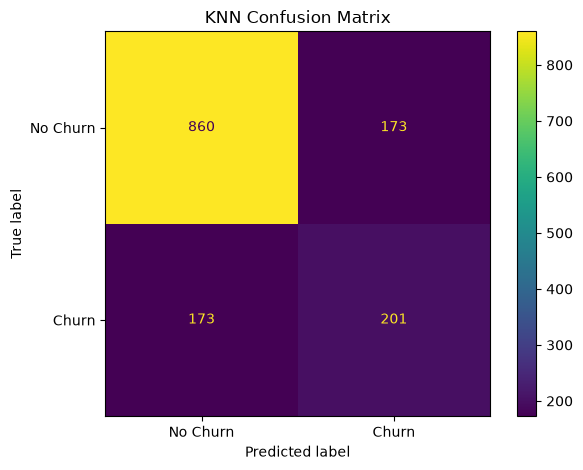


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.83      0.83      0.83      1033
       Churn       0.54      0.54      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [25]:
# ==================================================
# MAKE PREDICTIONS AND EVALUATE
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")


# Confusion Matrix
print("\n" + "=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()


# Classification Report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

In [26]:
# ==================================================
# EXPERIMENT WITH DIFFERENT K VALUES
# ==================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

k_values = [1, 3, 5, 7, 9, 11, 15]

results = []

for k in k_values:
    
    # Create and train KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results.append({
        "K": k,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("KNN PERFORMANCE COMPARISON")
print("=" * 60)

print(results_df.round(3))


KNN PERFORMANCE COMPARISON
    K  Accuracy  Precision  Recall  F1 Score
0   1     0.725      0.484   0.511     0.497
1   3     0.744      0.518   0.545     0.531
2   5     0.754      0.537   0.537     0.537
3   7     0.749      0.528   0.532     0.530
4   9     0.765      0.559   0.553     0.556
5  11     0.770      0.569   0.548     0.559
6  15     0.771      0.573   0.543     0.558


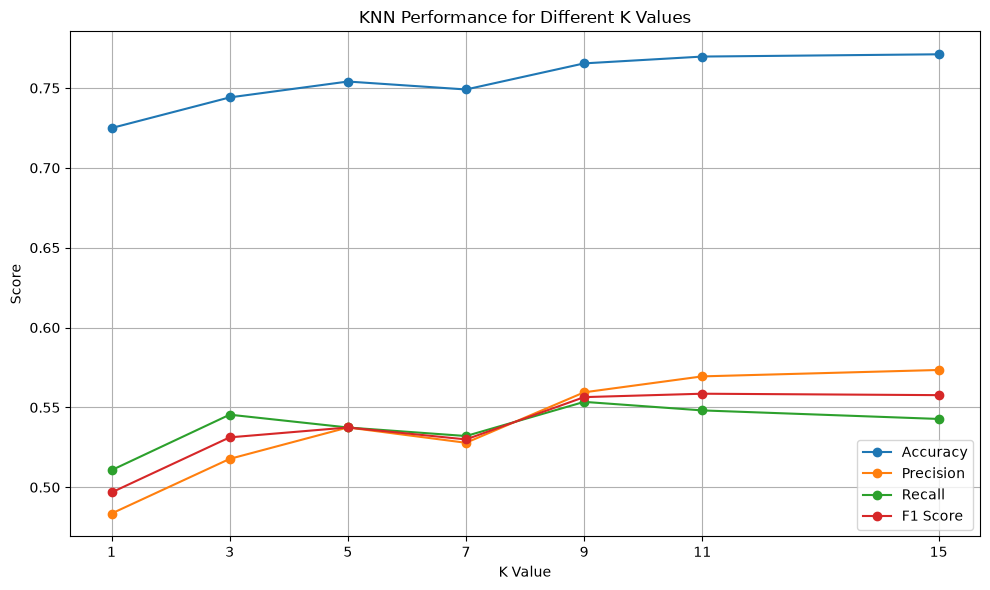

In [27]:
# ==================================================
# VISUALIZE K PERFORMANCE
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["K"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["K"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    results_df["K"],
    results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("K Value")
plt.ylabel("Score")
plt.title("KNN Performance for Different K Values")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [28]:
best_k = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "K"
]

print(f"Best K based on F1 Score: {best_k}")

Best K based on F1 Score: 11


In [29]:
# Train the final KNN model
knn_final = KNeighborsClassifier(n_neighbors=11)

knn_final.fit(X_train_scaled, y_train)

# Make predictions
y_pred_final = knn_final.predict(X_test_scaled)

In [30]:
print("Final KNN Model (K=11)")
print("=" * 50)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_final):.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Churn", "Churn"]
    )
)

Final KNN Model (K=11)
Accuracy:  0.770
Precision: 0.569
Recall:    0.548
F1 Score:  0.559

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.84      1033
       Churn       0.57      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



### Final Model Evaluation:
The final KNN model used K=11, which achieved the highest F1 score among the tested K values. The model achieved 77.0% accuracy on the test set. For the churn class, precision was 56.9%, recall was 54.8%, and the F1 score was 55.9%. The model performed substantially better at identifying customers who did not churn than customers who did. This indicates that although the model provides reasonable overall classification performance, there is still considerable room for improvement in detecting customers at risk of churn.